У официальномго сайта Yahoo finance (https://finance.yahoo.com/) отсутствует официальный api, при этом у неофициального yfinance, который является python библиотекой, нет официальной документации на эндпоинты. Поэтому данные о котировках мы решили парсить самостоятельно вручную.

Изначально мы попробовали сделать это так же с использованием библиотек requests и bs4, но yahoo finance блокируют парсинг своего сайта и при первой же попытке get, сайт выдает response 429 - too many requests. 

In [ ]:
import requests

In [ ]:
url = 'https://finance.yahoo.com/quote/AAPL/history/'
page = requests.get(url)
page

Поэтому мы использовали библиотеку Selenuim, которая имитирует человеческое поведение, тем самым обходя блокировку парсинга.

Будем рассмотривать 8 иностранных компаний из разных отраслей, чтобы наш анализ был более обширным. Мы выбрали монополистов крупных сфер: Apple (технологии), Exxon Mobil (энергетика), Tesla (автопром), Walmart (ритейл), Pfizer (медицина), Netflix (медиа), JPMorgan (финансы), Caterpillar (индустрия).

Импортируем все библиотеки

In [1]:

import time
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from datetime import datetime
import pandas as pd
import numpy as np
import re

Мы будем рассматривать период с 01.01.2021-09.04.2026, выпишем тикеры выбранных компаний (AAPL, XOM, TSLA, WMT, PFE, NFLX, JPM, CAT)

In [2]:
startdate = datetime(2021, 1, 1).timestamp()
enddate = datetime(2026, 4, 9).timestamp()

При загрузке сайта появляется соглашение cookie файлов, поэтому через click() закрываем уведомление.

In [3]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

ticker = 'AAPL'
url = f'https://finance.yahoo.com/quote/{ticker}/history/?period1={startdate}&period2={enddate}'
driver.get(url)

try:
    accept = WebDriverWait(driver, 3).until(EC.element_to_be_clickable((By.XPATH, "//button[contains(text(), 'Accept all')]")))
    accept.click()
except:
    pass

Затем возьмем шапку таблицы у компании Apple (она у всех компаний одинаковая, просто, чтобы данные добавлялись без дополнительных строчек). Извлекаем заголовки со страницы.

In [4]:
headers = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/thead/tr')
headers.text

'Date Open High Low Close\nAdj Close\nVolume'

`Date` - дата, когда зафиксирована цена акции

`Open` - цена первой сделки по акции

`High` - самая большая цена по акции

`Low` - самая низкая цена по акции

`Close` - цена последней сделки по акции

`Adj Close` - скорректированная цена последней сделки

`Volume` - количество акций проданных и купленных за выбранную дату

In [5]:
t = headers.text.split('\n')
cols = t[0].split() + t[1:]
cols

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

In [6]:
table = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/tbody')
table.text

'Apr 8, 2026 258.45 259.75 256.53 258.90 258.90 41,032,800\nApr 7, 2026 256.16 256.20 245.70 253.50 253.50 62,148,000\nApr 6, 2026 256.51 262.16 256.46 258.86 258.86 29,329,900\nApr 2, 2026 254.20 256.13 250.65 255.92 255.92 31,289,400\nApr 1, 2026 254.08 256.18 253.33 255.63 255.63 40,059,400\nMar 31, 2026 247.91 255.48 247.10 253.79 253.79 49,598,100\nMar 30, 2026 250.07 250.87 245.51 246.63 246.63 39,446,200\nMar 27, 2026 253.90 255.49 248.07 248.80 248.80 47,900,000\nMar 26, 2026 252.12 257.00 250.77 252.89 252.89 41,796,700\nMar 25, 2026 254.10 255.00 251.60 252.62 252.62 28,476,700\nMar 24, 2026 250.35 254.83 249.55 251.64 251.64 45,152,300\nMar 23, 2026 253.97 254.60 250.28 251.49 251.49 40,546,100\nMar 20, 2026 247.98 249.20 246.00 247.99 247.99 88,331,100\nMar 19, 2026 249.40 251.83 247.30 248.96 248.96 34,864,100\nMar 18, 2026 252.63 254.94 249.00 249.94 249.94 35,757,900\nMar 17, 2026 252.96 255.13 252.18 254.23 254.23 32,361,600\nMar 16, 2026 252.11 253.89 249.88 252.82 252

Также есть строчки с дивидендами и какая-то информация про stocks (которую Вера не отскринила и теперь не может найти, что там именно было), мы их не берем

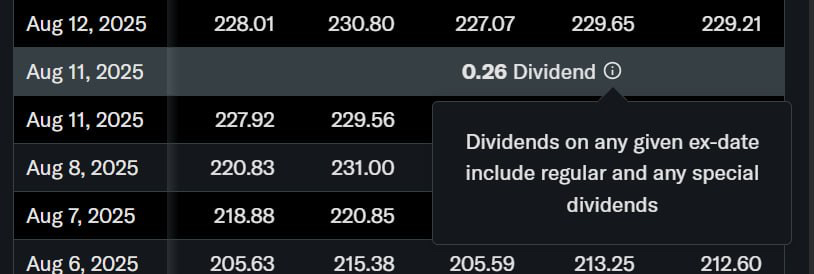

И наконец собираем наш датасет

In [14]:
df_list = []
for i in table.text.split('\n'):
    date = re.match(r'(\w+) (\d+), (\d+)', i)
    d = [f'{date.group(1)} {date.group(2)}, {date.group(3)}']
    spl = i.split()
    if 'Dividend' in spl or 'Stock' in spl:
        continue

    val = list(map(float, spl[3:-1]))
    volume = float(spl[-1].replace(',', ''))

    d.extend(val)
    d.append(volume)

    df_list.append(d)

df_list

[['Apr 8, 2026', 258.45, 259.75, 256.53, 258.9, 258.9, 41032800.0],
 ['Apr 7, 2026', 256.16, 256.2, 245.7, 253.5, 253.5, 62148000.0],
 ['Apr 6, 2026', 256.51, 262.16, 256.46, 258.86, 258.86, 29329900.0],
 ['Apr 2, 2026', 254.2, 256.13, 250.65, 255.92, 255.92, 31289400.0],
 ['Apr 1, 2026', 254.08, 256.18, 253.33, 255.63, 255.63, 40059400.0],
 ['Mar 31, 2026', 247.91, 255.48, 247.1, 253.79, 253.79, 49598100.0],
 ['Mar 30, 2026', 250.07, 250.87, 245.51, 246.63, 246.63, 39446200.0],
 ['Mar 27, 2026', 253.9, 255.49, 248.07, 248.8, 248.8, 47900000.0],
 ['Mar 26, 2026', 252.12, 257.0, 250.77, 252.89, 252.89, 41796700.0],
 ['Mar 25, 2026', 254.1, 255.0, 251.6, 252.62, 252.62, 28476700.0],
 ['Mar 24, 2026', 250.35, 254.83, 249.55, 251.64, 251.64, 45152300.0],
 ['Mar 23, 2026', 253.97, 254.6, 250.28, 251.49, 251.49, 40546100.0],
 ['Mar 20, 2026', 247.98, 249.2, 246.0, 247.99, 247.99, 88331100.0],
 ['Mar 19, 2026', 249.4, 251.83, 247.3, 248.96, 248.96, 34864100.0],
 ['Mar 18, 2026', 252.63, 254.9

In [11]:
df = pd.DataFrame(df_list, columns=cols)
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,"Apr 8, 2026",258.45,259.75,256.53,258.90,258.90,41032800.0
1,"Apr 7, 2026",256.16,256.20,245.70,253.50,253.50,62148000.0
2,"Apr 6, 2026",256.51,262.16,256.46,258.86,258.86,29329900.0
3,"Apr 2, 2026",254.20,256.13,250.65,255.92,255.92,31289400.0
4,"Apr 1, 2026",254.08,256.18,253.33,255.63,255.63,40059400.0
...,...,...,...,...,...,...,...
1317,"Jan 7, 2021",128.36,131.63,127.86,130.92,127.33,109578200.0
1318,"Jan 6, 2021",127.72,131.05,126.38,126.60,123.12,155088000.0
1319,"Jan 5, 2021",128.89,131.74,128.43,131.01,127.41,97664900.0
1320,"Jan 4, 2021",133.52,133.61,126.76,129.41,125.86,143301900.0


In [13]:
driver.quit()

Таким образом, мы сделали для компании Apple. Теперь соберем всё в цикл, пройдя по всем компаниям

Полный код со всеми компаниями ниже

In [ ]:
import logging
from logger_config import logs, details

filen = 'Parsing Vera_Rena'

if logs & details:
    logging.basicConfig(level=logging.INFO, filename="py_log.log",filemode="a",
                    format="%(asctime)s %(levelname)s %(message)s")
    try:
    
        startdate = datetime(2021, 1, 1).timestamp()
        enddate = datetime(2026, 4, 9).timestamp()

        df_list = []

        for ticker in ['AAPL', 'XOM', 'TSLA', 'WMT', 'PFE', 'NFLX', 'JPM', 'CAT']:
            service = Service(ChromeDriverManager().install())
            driver = webdriver.Chrome(service=service)

            url = f'https://finance.yahoo.com/quote/{ticker}/history/?period1={startdate}&period2={enddate}'
            driver.get(url)
            logging.info(f"{filen}, site loaded")
            try:
                accept = WebDriverWait(driver, 3).until(EC.element_to_be_clickable((By.XPATH, "//button[contains(text(), 'Accept all')]")))
                accept.click()
                logging.info(f"{filen}, cookies passed")
            except:
                logging.error(f"{filen}, no cookies acception or button has not loaded")

            if ticker == 'AAPL':
                headers = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/thead/tr')
                t = headers.text.split('\n')
                cols = t[0].split() + t[1:]
                cols.insert(0, 'ticker')
                logging.info(f"{filen}, headers were loaded")
                
            table = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/tbody')

            for i in table.text.split('\n'):
                spl = i.split()

                if 'Dividend' in spl  or 'Stock' in spl:
                    continue

                d = list(spl)[:3]
                d[0] = f'{d[0]} {d[1]} {d[2]}'
                d.pop(1)
                d.pop(1)

                val = list(map(float, spl[3:-1]))
                volume = float(spl[-1].replace(',', ''))

                d.extend(val)
                d.append(volume)
                d.insert(0, ticker)
                df_list.append(d)

            driver.quit()
            time.sleep(1)


        df = pd.DataFrame(df_list, columns=cols)
        driver.quit()
        logging.info(f"{filen}, success. dataframe is done")

    except Exception as e:
        logging.error(f"{filen}, error {e}")

elif logs & details == False:
    logging.basicConfig(level=logging.INFO, filename="py_log.log",filemode="a",
                    format="%(asctime)s %(levelname)s %(message)s")
    try:
    
        startdate = datetime(2021, 1, 1).timestamp()
        enddate = datetime(2026, 4, 9).timestamp()

        df_list = []

        for ticker in ['AAPL', 'XOM', 'TSLA', 'WMT', 'PFE', 'NFLX', 'JPM', 'CAT']:
            service = Service(ChromeDriverManager().install())
            driver = webdriver.Chrome(service=service)

            url = f'https://finance.yahoo.com/quote/{ticker}/history/?period1={startdate}&period2={enddate}'
            driver.get(url)
            
            try:
                accept = WebDriverWait(driver, 3).until(EC.element_to_be_clickable((By.XPATH, "//button[contains(text(), 'Accept all')]")))
                accept.click()
            except:
                pass

            if ticker == 'AAPL':
                headers = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/thead/tr')
                t = headers.text.split('\n')
                cols = t[0].split() + t[1:]
                cols.insert(0, 'ticker')

            table = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/tbody')

            for i in table.text.split('\n'):
                spl = i.split()

                if 'Dividend' in spl  or 'Stock' in spl:
                    continue

                d = list(spl)[:3]
                d[0] = f'{d[0]} {d[1]} {d[2]}'
                d.pop(1)
                d.pop(1)

                val = list(map(float, spl[3:-1]))
                volume = float(spl[-1].replace(',', ''))

                d.extend(val)
                d.append(volume)
                d.insert(0, ticker)
                df_list.append(d)

            driver.quit()
            time.sleep(1)


        df = pd.DataFrame(df_list, columns=cols)
        driver.quit()
        logging.info(f"{filen}, success. dataframe is done")
    except Exception as e:
        logging.error(f"{filen}, error {e}")

else:
    startdate = datetime(2021, 1, 1).timestamp()
    enddate = datetime(2026, 4, 9).timestamp()

    df_list = []

    for ticker in ['AAPL', 'XOM', 'TSLA', 'WMT', 'PFE', 'NFLX', 'JPM', 'CAT']:
        service = Service(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=service)

        url = f'https://finance.yahoo.com/quote/{ticker}/history/?period1={startdate}&period2={enddate}'
        driver.get(url)
        
        try:
            accept = WebDriverWait(driver, 3).until(EC.element_to_be_clickable((By.XPATH, "//button[contains(text(), 'Accept all')]")))
            accept.click()
        except:
            pass

        if ticker == 'AAPL':
            headers = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/thead/tr')
            t = headers.text.split('\n')
            cols = t[0].split() + t[1:]
            cols.insert(0, 'ticker')

        table = driver.find_element(By.XPATH, '//*[@id="main-content-wrapper"]/div[1]/div[3]/table/tbody')

        for i in table.text.split('\n'):
            spl = i.split()

            if 'Dividend' in spl  or 'Stock' in spl:
                continue

            d = list(spl)[:3]
            d[0] = f'{d[0]} {d[1]} {d[2]}'
            d.pop(1)
            d.pop(1)

            val = list(map(float, spl[3:-1]))
            volume = float(spl[-1].replace(',', ''))

            d.extend(val)
            d.append(volume)
            d.insert(0, ticker)
            df_list.append(d)

        driver.quit()
        time.sleep(1)


    df = pd.DataFrame(df_list, columns=cols)
    driver.quit()

In [5]:
df

,ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,"Apr 8, 2026",258.45,259.75,256.53,258.90,258.90,41032800.0
1,AAPL,"Apr 7, 2026",256.16,256.20,245.70,253.50,253.50,62148000.0
2,AAPL,"Apr 6, 2026",256.51,262.16,256.46,258.86,258.86,29329900.0
3,AAPL,"Apr 2, 2026",254.20,256.13,250.65,255.92,255.92,31289400.0
4,AAPL,"Apr 1, 2026",254.08,256.18,253.33,255.63,255.63,40059400.0
...,...,...,...,...,...,...,...,...
10571,CAT,"Jan 7, 2021",196.85,197.37,192.20,194.23,176.20,5297500.0
10572,CAT,"Jan 6, 2021",187.15,197.28,186.15,193.86,175.87,8034700.0
10573,CAT,"Jan 5, 2021",181.21,185.80,181.21,183.64,166.60,2933700.0
10574,CAT,"Jan 4, 2021",183.00,185.98,180.25,182.15,165.24,4078300.0


In [ ]:
df.to_csv('quotes_all.csv')

Сохраним датасет в `quotes_all.csv`